# Assessment Analysis: Quiz Names and Grade Linkage

This notebook analyzes:
- Top 20 Most Common Quiz Names
- Quiz-Grade Object Linkage

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
base_path = Path('../etl-output')

grades_path = base_path / 'grades' / 'gradeobjects' / 'data'
quizzes_path = base_path / 'quizzes' / 'quizobjects' / 'data'

### Load Quizzes Dataset

In [3]:
print("Loading Quizzes dataset...")
quiz_files = sorted(glob.glob(str(quizzes_path / 'part-*.csv')))
print(f"Found {len(quiz_files)} CSV files")

df_quizzes = pd.concat([pd.read_csv(f, low_memory=False) for f in quiz_files], ignore_index=True)
print(f"Loaded {len(df_quizzes):,} quizzes")
print(f"Columns: {df_quizzes.shape[1]}")
df_quizzes.head()

Loading Quizzes dataset...
Found 1 CSV files
Loaded 701,708 quizzes
Columns: 37


,quiz_id,quiz_name,quiz_description,quiz_category,is_active,org_unit_id,start_date,end_date,due_date,creation_date,created_by,last_modified,last_modified_by,grade_object_id,overall_score_calculation,quiz_score_denominator,has_password,ip_restricted,time_limit,time_limit_enforced,attempts_allowed,prevent_moving_backwards,allow_hints,notification_email,disable_pager_access,display_in_calendar,is_attempt_rldb,is_subview_rldb,sort_order,category_id,result_id,is_retake_incorrect_only,paging_type_id,is_synchronous,deduction_percentage,ai_study_support,hide_question_points
0,1075338,test,NaN,NaN,False,1214190,NaN,NaN,NaN,2026-02-06T17:53:59,NaN,2026-02-06T17:54:14,537294.0,NaN,Highest Attempt,0.0,False,False,0,False,1.0,False,False,NaN,False,False,False,False,1,NaN,NaN,False,0.0,False,NaN,False,False
1,1075329,Final Exam Online - Instructor Answer Key,NaN,Instructor Answer Key,False,1214064,NaN,NaN,NaN,2026-02-06T15:29:36,1047103.0,2026-02-06T15:48:17,144226.0,NaN,Highest Attempt,35.0,False,False,120,False,1.0,False,False,NaN,False,False,False,False,9,104622.0,NaN,False,NaN,False,NaN,False,False
2,1075328,"Final Exam Online (35qu, 41min)",NaN,Exams,False,1214064,NaN,NaN,NaN,2026-02-06T15:29:35,1047103.0,2026-02-06T15:48:38,144226.0,NaN,First Attempt,35.0,False,False,41,True,1.0,False,False,NaN,True,False,False,False,8,104618.0,NaN,False,NaN,False,NaN,False,False
3,1075327,Erj 2016-1522 Ch. 47 Suspension Systems,NaN,Erjavec 2016: Automotive Technology: A Systems...,True,1214064,2026-02-09T15:00:00,2026-02-20T22:00:00,NaN,2026-02-06T15:29:35,148675.0,2026-02-06T15:47:50,144226.0,1644816.0,Highest Attempt,30.0,False,False,120,False,NaN,False,False,NaN,True,True,False,False,7,104621.0,NaN,False,NaN,False,NaN,False,False
4,1075326,ALG Frames,NaN,Alberta Learning Guide (ALG) - Self-Tests [MC ...,True,1214064,2026-02-09T15:00:00,2026-02-20T22:00:00,NaN,2026-02-06T15:29:35,148675.0,2026-02-06T15:47:50,144226.0,1644817.0,Highest Attempt,11.0,False,False,120,False,NaN,False,False,NaN,False,True,False,False,6,104620.0,NaN,False,NaN,False,NaN,False,False


### Load Grade Objects Dataset

In [4]:
print("Loading Grade Objects dataset...")
grade_files = sorted(glob.glob(str(grades_path / 'part-*.csv')))
print(f"Found {len(grade_files)} CSV files")

df_grades = pd.concat([pd.read_csv(f, low_memory=False) for f in grade_files], ignore_index=True)
print(f"Loaded {len(df_grades):,} grade objects")
print(f"Columns: {df_grades.shape[1]}")
df_grades.head()

Loading Grade Objects dataset...
Found 4 CSV files
Loaded 1,602,181 grade objects
Columns: 31


,grade_object_id,org_unit_id,parent_grade_object_id,name,type_name,start_date,end_date,is_auto_pointed,is_formula,is_bonus,max_points,can_exceed_max_grade,exclude_from_final_grade_calc,grade_scheme_id,weight,num_lowest_grades_to_drop,num_highest_grades_to_drop,weight_distribution_type,created_date,tool_name,associated_tool_item_id,last_modified,short_name,grade_object_type_id,sort_order,is_deleted,deleted_date,deleted_by_user_id,result_id,tool_id,version
0,1040040,849714,1040038.0,Quiz Two,Numeric,NaN,NaN,False,False,False,20.0,False,False,NaN,25.000,0,0,NaN,2022-04-28T15:04:51,NaN,NaN,2022-04-28T15:04:51,NaN,1,21,False,NaN,NaN,NaN,NaN,2
1,1040041,849714,1040038.0,Quiz Three,Numeric,NaN,NaN,False,False,False,20.0,False,False,NaN,25.000,0,0,NaN,2022-04-28T15:04:51,NaN,NaN,2022-04-28T15:04:51,NaN,1,22,False,NaN,NaN,NaN,NaN,2
2,1040042,849714,1040038.0,Quiz Four,Numeric,NaN,NaN,False,False,False,20.0,False,False,NaN,25.000,0,0,NaN,2022-04-28T15:04:51,NaN,NaN,2022-04-28T15:04:51,NaN,1,23,False,NaN,NaN,NaN,NaN,2
3,1040043,847734,NaN,Theory,Category,NaN,NaN,False,False,False,10.0,False,False,NaN,40.000,0,0,Manual,2022-04-28T15:05:23,NaN,NaN,2022-04-28T15:05:22,Theory,9,1,False,NaN,NaN,NaN,NaN,2
4,1040044,847734,1040043.0,Electrical Test Instruments,Numeric,NaN,NaN,False,False,False,40.0,False,False,NaN,0.606,0,0,NaN,2022-04-28T15:05:23,Quizzes,704757.0,2022-04-28T15:05:22,NaN,1,2,False,NaN,NaN,NaN,51000.0,2


## Top 10 Most Common Quiz Names (with Other)

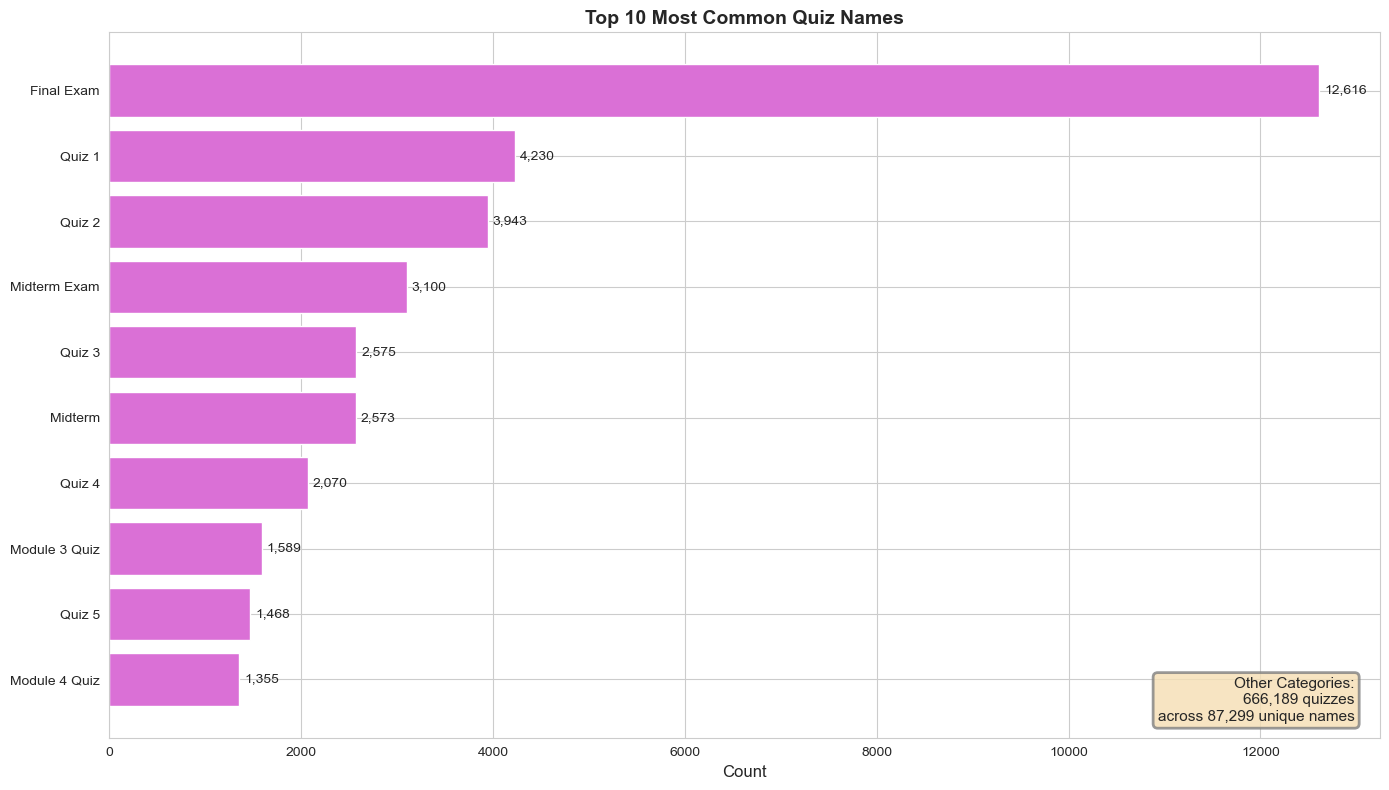

In [8]:
top_10_quiz_names = df_quizzes['quiz_name'].value_counts().head(10)
other_count = df_quizzes['quiz_name'].value_counts().iloc[10:].sum()
unique_other_names = len(df_quizzes['quiz_name'].value_counts().iloc[10:])

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(len(top_10_quiz_names)), top_10_quiz_names.values, color='orchid')
ax.set_yticks(range(len(top_10_quiz_names)))
ax.set_yticklabels(top_10_quiz_names.index)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Top 10 Most Common Quiz Names', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_10_quiz_names.values):
    ax.text(v + 50, i, f'{v:,}', va='center')

textstr = f'Other Categories:\n{other_count:,} quizzes\nacross {unique_other_names:,} unique names'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='gray', linewidth=2)
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

## Quiz Name Trends Over Time

### Distribution by Year and Term

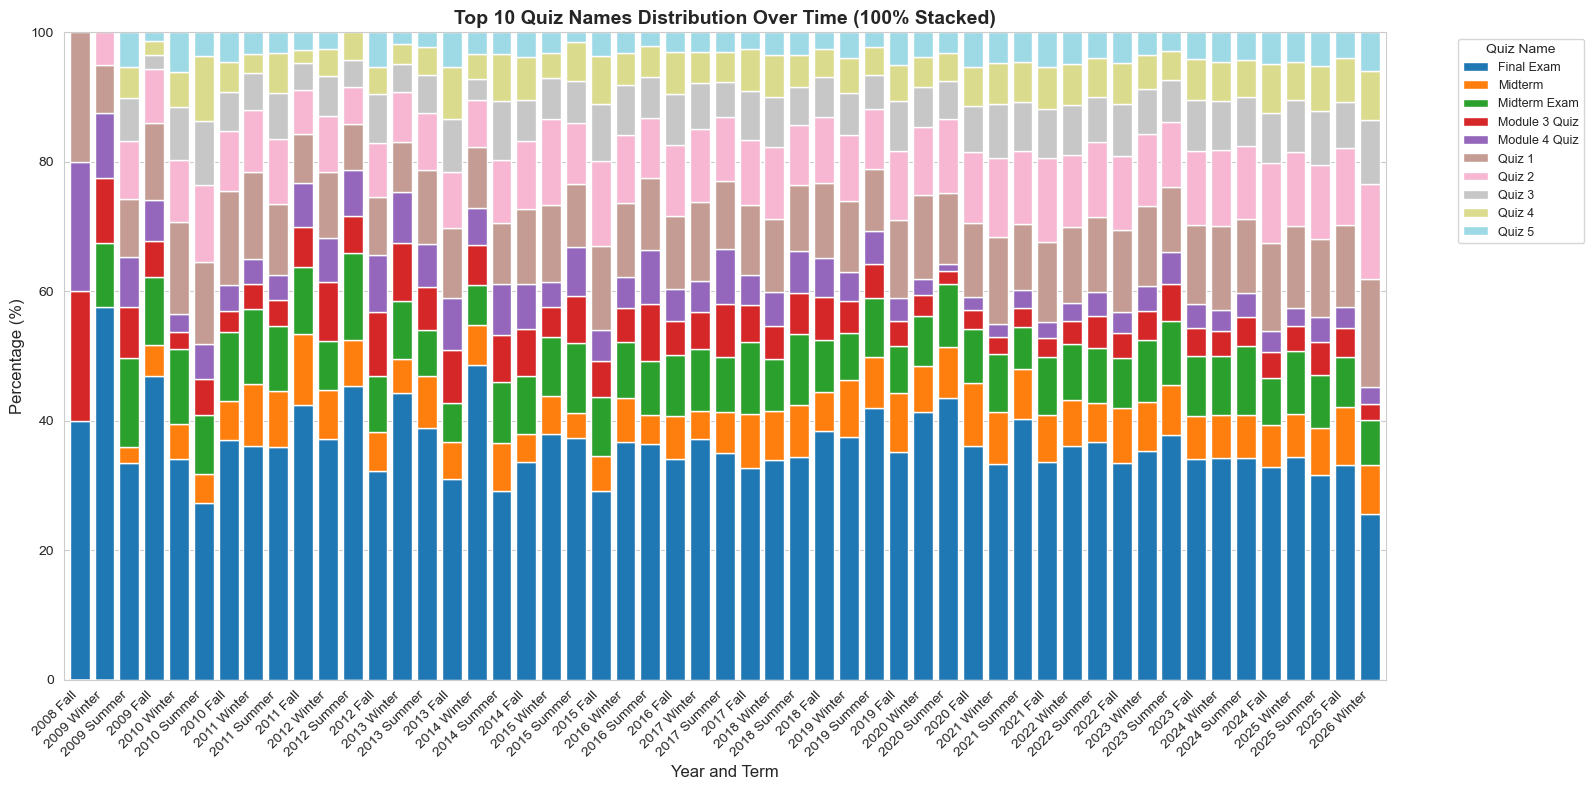


Total quizzes by year-term:
year_term
2008 Fall         5
2009 Winter      40
2009 Summer     167
2009 Fall       143
2010 Winter     147
2010 Summer     110
2010 Fall       151
2011 Winter     208
2011 Summer     128
2011 Fall       146
2012 Winter     264
2012 Summer     141
2012 Fall       264
2013 Winter     325
2013 Summer     226
2013 Fall       297
2014 Winter     305
2014 Summer     244
2014 Fall       345
2015 Winter     480
2015 Summer     265
2015 Fall       494
2016 Winter     503
2016 Summer     333
2016 Fall       469
2017 Winter     549
2017 Summer     365
2017 Fall       432
2018 Winter     617
2018 Summer     399
2018 Fall       551
2019 Winter     698
2019 Summer     450
2019 Fall       713
2020 Winter    1174
2020 Summer     937
2020 Fall      1906
2021 Winter    1989
2021 Summer    1104
2021 Fall      1629
2022 Winter    1408
2022 Summer     824
2022 Fall      1328
2023 Winter    1371
2023 Summer     827
2023 Fall      1412
2024 Winter    1532
2024 Summer    1056
2

In [9]:
df_quizzes['creation_date_parsed'] = pd.to_datetime(df_quizzes['creation_date'], errors='coerce')
df_quizzes['year'] = df_quizzes['creation_date_parsed'].dt.year
df_quizzes['month'] = df_quizzes['creation_date_parsed'].dt.month

def get_term(month):
    if pd.isna(month):
        return 'Unknown'
    elif month in [1, 2, 3, 4]:
        return 'Winter'
    elif month in [5, 6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_quizzes['term'] = df_quizzes['month'].apply(get_term)
df_quizzes['year_term'] = df_quizzes['year'].astype(str) + ' ' + df_quizzes['term']

top_10_names = df_quizzes['quiz_name'].value_counts().head(10).index.tolist()

df_filtered = df_quizzes[df_quizzes['quiz_name'].isin(top_10_names)].copy()
df_filtered.loc[~df_filtered['quiz_name'].isin(top_10_names), 'quiz_name'] = 'Other'

trend_data = df_filtered.groupby(['year_term', 'quiz_name']).size().unstack(fill_value=0)

year_term_order = df_quizzes[df_quizzes['year_term'] != 'nan Unknown'].groupby('year_term')['creation_date_parsed'].min().sort_values().index.tolist()
trend_data = trend_data.reindex(year_term_order, fill_value=0)

trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
trend_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)

ax.set_xlabel('Year and Term', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Top 10 Quiz Names Distribution Over Time (100% Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Quiz Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal quizzes by year-term:")
print(df_filtered.groupby('year_term').size().reindex(year_term_order))

### Distribution by 5-Year Intervals

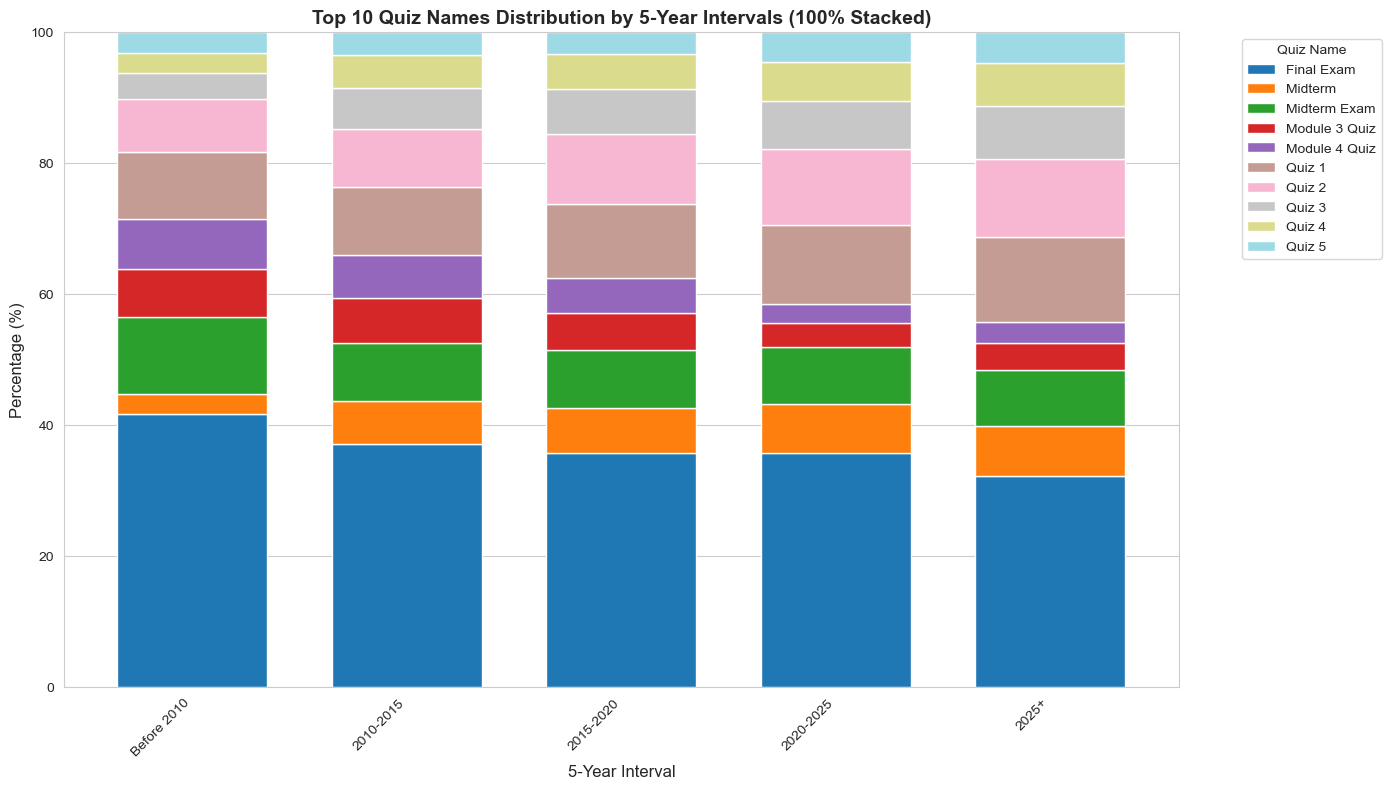


Total quizzes by 5-year interval:
interval
Before 2010      355
2010-2015       3301
2015-2020       7318
2020-2025      19851
2025+           4694
dtype: int64


In [10]:
def assign_interval(year):
    if pd.isna(year):
        return 'Unknown'
    elif 2010 <= year < 2015:
        return '2010-2015'
    elif 2015 <= year < 2020:
        return '2015-2020'
    elif 2020 <= year < 2025:
        return '2020-2025'
    elif year >= 2025:
        return '2025+'
    else:
        return 'Before 2010'

df_quizzes['interval'] = df_quizzes['year'].apply(assign_interval)

top_10_names_interval = df_quizzes['quiz_name'].value_counts().head(10).index.tolist()

df_interval_filtered = df_quizzes[df_quizzes['quiz_name'].isin(top_10_names_interval)].copy()

interval_data = df_interval_filtered.groupby(['interval', 'quiz_name']).size().unstack(fill_value=0)

interval_order = ['Before 2010', '2010-2015', '2015-2020', '2020-2025', '2025+', 'Unknown']
interval_data = interval_data.reindex([i for i in interval_order if i in interval_data.index], fill_value=0)

interval_pct = interval_data.div(interval_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
interval_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.7)

ax.set_xlabel('5-Year Interval', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Top 10 Quiz Names Distribution by 5-Year Intervals (100% Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Quiz Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal quizzes by 5-year interval:")
print(df_interval_filtered.groupby('interval').size().reindex([i for i in interval_order if i in df_interval_filtered['interval'].unique()]))

## Quiz-Grade Object Linkage

Quizzes with Grade Object ID: 278,197 (39.6%)
Quizzes without Grade Object ID: 423,511 (60.4%)


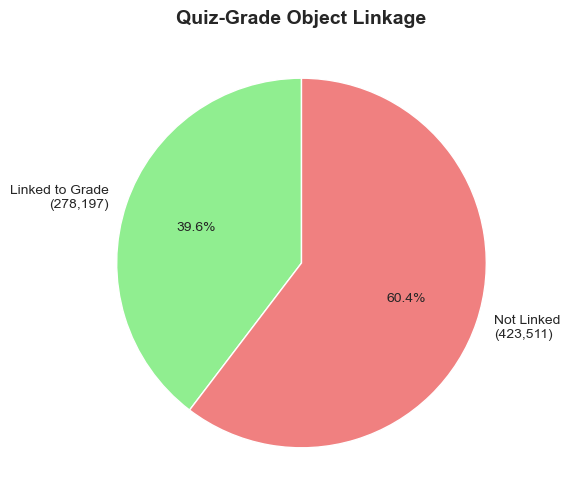

In [6]:
quizzes_with_grade = df_quizzes[df_quizzes['grade_object_id'].notna()]
quizzes_without_grade = df_quizzes[df_quizzes['grade_object_id'].isna()]

print(f"Quizzes with Grade Object ID: {len(quizzes_with_grade):,} ({len(quizzes_with_grade)/len(df_quizzes)*100:.1f}%)")
print(f"Quizzes without Grade Object ID: {len(quizzes_without_grade):,} ({len(quizzes_without_grade)/len(df_quizzes)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
linkage_data = [len(quizzes_with_grade), len(quizzes_without_grade)]
linkage_labels = [f'Linked to Grade\n({len(quizzes_with_grade):,})', f'Not Linked\n({len(quizzes_without_grade):,})']
colors = ['lightgreen', 'lightcoral']
ax.pie(linkage_data, labels=linkage_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Quiz-Grade Object Linkage', fontsize=14, fontweight='bold')
plt.show()

### Courses Using Both Quizzes and Grade Objects Without Linking

In [11]:
# Identify courses that have both quizzes and grade objects
courses_with_quizzes = set(df_quizzes['org_unit_id'].unique())
courses_with_grades = set(df_grades['org_unit_id'].unique())

# Courses with both quizzes and grade objects
courses_with_both = courses_with_quizzes & courses_with_grades

print(f"Total courses with quizzes: {len(courses_with_quizzes):,}")
print(f"Total courses with grade objects: {len(courses_with_grades):,}")
print(f"Courses with both quizzes and grade objects: {len(courses_with_both):,}")

# For courses with both, check if any quizzes are linked to grade objects
courses_with_linkage = set()
for course_id in courses_with_both:
    course_quizzes = df_quizzes[df_quizzes['org_unit_id'] == course_id]
    if course_quizzes['grade_object_id'].notna().any():
        courses_with_linkage.add(course_id)

courses_with_both_but_no_linkage = courses_with_both - courses_with_linkage

print(f"\nCourses with linked quizzes: {len(courses_with_linkage):,}")
print(f"Courses with both but NO linkage: {len(courses_with_both_but_no_linkage):,}")
print(f"Percentage of courses with both that don't link: {len(courses_with_both_but_no_linkage)/len(courses_with_both)*100:.1f}%")

Total courses with quizzes: 61,365
Total courses with grade objects: 189,169
Courses with both quizzes and grade objects: 61,308

Courses with linked quizzes: 44,423
Courses with both but NO linkage: 16,885
Percentage of courses with both that don't link: 27.5%


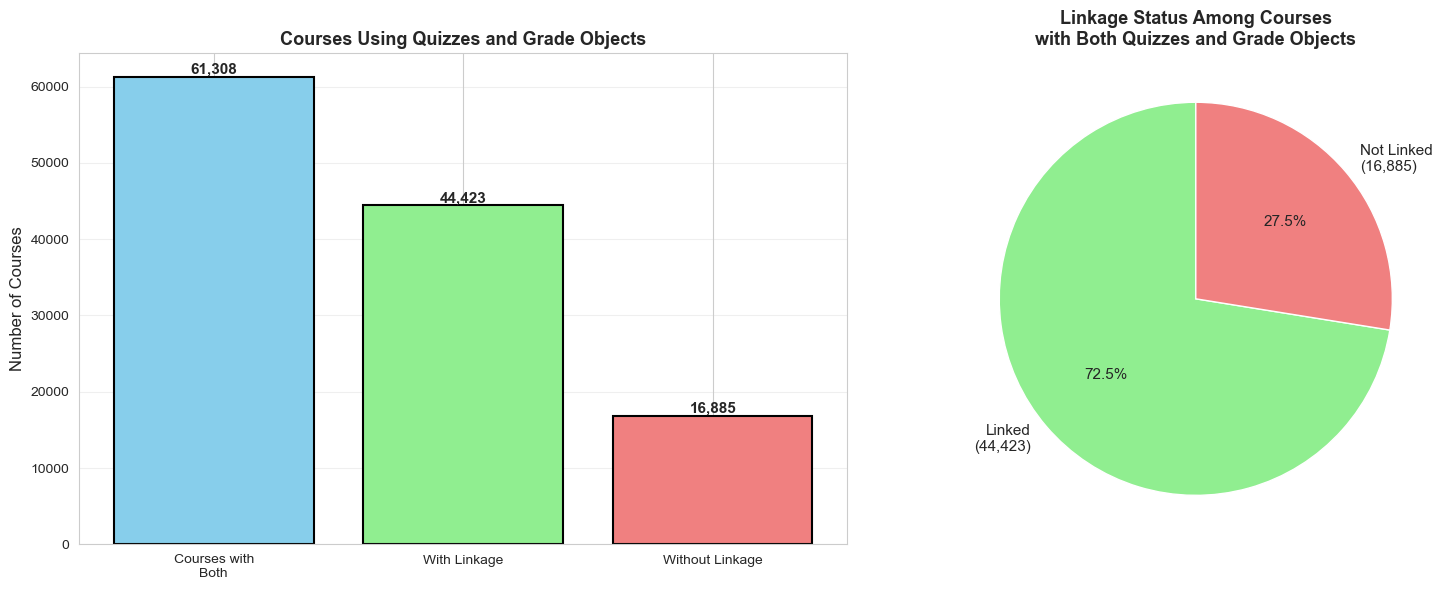


KEY INSIGHT:
Out of 61,308 courses that have BOTH quizzes and grade objects,
16,885 courses (27.5%) are NOT linking them together.


In [12]:
# Visualize the breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Overall course breakdown
categories = ['Courses with\nBoth', 'With Linkage', 'Without Linkage']
values = [len(courses_with_both), len(courses_with_linkage), len(courses_with_both_but_no_linkage)]
colors_chart1 = ['skyblue', 'lightgreen', 'lightcoral']

bars1 = ax1.bar(categories, values, color=colors_chart1, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Courses', fontsize=12)
ax1.set_title('Courses Using Quizzes and Grade Objects', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Pie chart of linkage status among courses with both
linkage_status = [len(courses_with_linkage), len(courses_with_both_but_no_linkage)]
linkage_labels = [f'Linked\n({len(courses_with_linkage):,})', 
                  f'Not Linked\n({len(courses_with_both_but_no_linkage):,})']
colors_chart2 = ['lightgreen', 'lightcoral']

ax2.pie(linkage_status, labels=linkage_labels, autopct='%1.1f%%', 
        colors=colors_chart2, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Linkage Status Among Courses\nwith Both Quizzes and Grade Objects', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n{'='*60}")
print("KEY INSIGHT:")
print(f"{'='*60}")
print(f"Out of {len(courses_with_both):,} courses that have BOTH quizzes and grade objects,")
print(f"{len(courses_with_both_but_no_linkage):,} courses ({len(courses_with_both_but_no_linkage)/len(courses_with_both)*100:.1f}%) are NOT linking them together.")
print(f"{'='*60}")

### Temporal Analysis: Quiz-Grade Linkage Over Time

In [13]:
# Create time period bins for temporal analysis
def assign_time_period(year):
    if pd.isna(year):
        return 'Unknown'
    elif 2010 <= year <= 2015:
        return '2010-2015'
    elif 2016 <= year <= 2020:
        return '2016-2020'
    elif 2021 <= year <= 2025:
        return '2021-2025'
    else:
        return 'Other'

df_quizzes['time_period'] = df_quizzes['year'].apply(assign_time_period)

# Calculate linkage statistics by time period
time_periods = ['2010-2015', '2016-2020', '2021-2025']
linkage_by_period = []

for period in time_periods:
    period_quizzes = df_quizzes[df_quizzes['time_period'] == period]
    total_quizzes = len(period_quizzes)
    linked_quizzes = len(period_quizzes[period_quizzes['grade_object_id'].notna()])
    unlinked_quizzes = total_quizzes - linked_quizzes
    
    linkage_by_period.append({
        'Period': period,
        'Linked': linked_quizzes,
        'Not Linked': unlinked_quizzes,
        'Total': total_quizzes,
        'Linked %': (linked_quizzes / total_quizzes * 100) if total_quizzes > 0 else 0
    })

linkage_df = pd.DataFrame(linkage_by_period)
print("Quiz-Grade Object Linkage by Time Period:")
print(linkage_df.to_string(index=False))
print()

Quiz-Grade Object Linkage by Time Period:
   Period  Linked  Not Linked  Total  Linked %
2010-2015   31036       87938 118974 26.086372
2016-2020   81221      124766 205987 39.430158
2021-2025  157681      204115 361796 43.582848



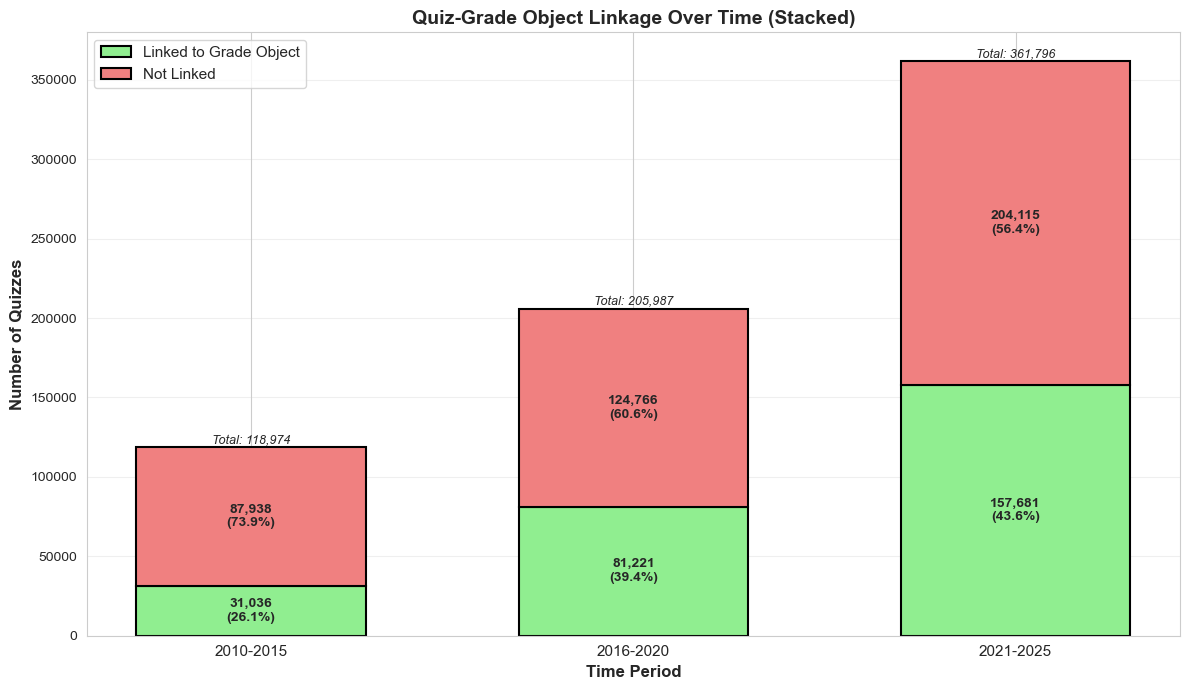


TEMPORAL TRENDS:
2010-2015: 26.1% linked (31,036 of 118,974 quizzes)
2016-2020: 39.4% linked (81,221 of 205,987 quizzes)
2021-2025: 43.6% linked (157,681 of 361,796 quizzes)


In [14]:
# Create stacked bar chart showing temporal changes
fig, ax = plt.subplots(figsize=(12, 7))

periods = linkage_df['Period'].tolist()
linked = linkage_df['Linked'].tolist()
not_linked = linkage_df['Not Linked'].tolist()

x = np.arange(len(periods))
width = 0.6

# Create stacked bars
bars1 = ax.bar(x, linked, width, label='Linked to Grade Object', color='lightgreen', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, not_linked, width, bottom=linked, label='Not Linked', color='lightcoral', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (p1, p2) in enumerate(zip(linked, not_linked)):
    # Linked section
    ax.text(i, p1/2, f'{p1:,}\n({linkage_df.iloc[i]["Linked %"]:.1f}%)', 
            ha='center', va='center', fontsize=10, fontweight='bold')
    # Not linked section
    ax.text(i, p1 + p2/2, f'{p2:,}\n({100-linkage_df.iloc[i]["Linked %"]:.1f}%)', 
            ha='center', va='center', fontsize=10, fontweight='bold')
    # Total on top
    ax.text(i, p1 + p2, f'Total: {p1+p2:,}', 
            ha='center', va='bottom', fontsize=9, style='italic')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Quizzes', fontsize=12, fontweight='bold')
ax.set_title('Quiz-Grade Object Linkage Over Time (Stacked)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=11)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary insights
print("\n" + "="*70)
print("TEMPORAL TRENDS:")
print("="*70)
for _, row in linkage_df.iterrows():
    print(f"{row['Period']}: {row['Linked %']:.1f}% linked ({row['Linked']:,} of {row['Total']:,} quizzes)")
print("="*70)